# Diffraction Classification: Jitter and Vacancy

In this notebook, we shift from regression to classification.

Instead of predicting exact values of:
- positional jitter (σ)
- vacancy fraction

we classify them into coarse categories:
- low
- medium
- high

This helps evaluate whether diffraction patterns preserve **coarse structural information** even when exact inversion is ambiguous.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [2]:
def create_lattice_with_jitter_vacancy(
    n_points=10,
    grid_size=128,
    jitter_sigma=0.0,
    vacancy_fraction=0.0
):
    img = np.zeros((grid_size, grid_size))

    spacing = grid_size / (n_points + 2)
    coords = np.arange(n_points) * spacing
    lattice_span = coords[-1] - coords[0]
    start = (grid_size - lattice_span) / 2.0

    for i in range(n_points):
        for j in range(n_points):

            if np.random.rand() < vacancy_fraction:
                continue

            x = start + i * spacing
            y = start + j * spacing

            x += np.random.normal(0, jitter_sigma * spacing)
            y += np.random.normal(0, jitter_sigma * spacing)

            xi = int(np.clip(round(x), 0, grid_size - 1))
            yi = int(np.clip(round(y), 0, grid_size - 1))

            img[yi, xi] = 1.0

    return img


def compute_diffraction(img, normalize=True):
    F = np.fft.fftshift(np.fft.fft2(img))
    I = np.abs(F) ** 2
    I_log = np.log1p(I)

    if normalize:
        I_log = (I_log - I_log.min()) / (I_log.max() - I_log.min() + 1e-8)

    return I_log

In [3]:
sigma_levels = [0.00, 0.03, 0.06, 0.09, 0.12, 0.15]
vacancy_levels = [0.00, 0.10, 0.20, 0.30, 0.40]

samples_per_combo = 100

n_points = 10
grid_size = 128

In [4]:
X = []
sigma_vals = []
vac_vals = []

for sigma in sigma_levels:
    for vacancy in vacancy_levels:
        for _ in range(samples_per_combo):

            img = create_lattice_with_jitter_vacancy(
                n_points=n_points,
                grid_size=grid_size,
                jitter_sigma=sigma,
                vacancy_fraction=vacancy
            )

            diff = compute_diffraction(img)

            X.append(diff)
            sigma_vals.append(sigma)
            vac_vals.append(vacancy)

X = np.array(X)
sigma_vals = np.array(sigma_vals)
vac_vals = np.array(vac_vals)

In [5]:
# Sigma bins
def sigma_to_class(s):
    if s <= 0.03:
        return 0   # low
    elif s <= 0.09:
        return 1   # medium
    else:
        return 2   # high

# Vacancy bins
def vac_to_class(v):
    if v == 0.0:
        return 0   # low
    elif v <= 0.20:
        return 1   # medium
    else:
        return 2   # high

sigma_labels = np.array([sigma_to_class(s) for s in sigma_vals])
vac_labels = np.array([vac_to_class(v) for v in vac_vals])

In [7]:
joint_labels = sigma_labels * 3 + vac_labels

print("Unique joint classes:", np.unique(joint_labels))

Unique joint classes: [0 1 2 3 4 5 6 7 8]


In [8]:
label_map = {
    0: "low σ, low v",
    1: "low σ, med v",
    2: "low σ, high v",
    3: "med σ, low v",
    4: "med σ, med v",
    5: "med σ, high v",
    6: "high σ, low v",
    7: "high σ, med v",
    8: "high σ, high v",
}

In [9]:
X_flat = X.reshape(len(X), -1)

X_train, X_test, y_train, y_test = train_test_split(
    X_flat, joint_labels, test_size=0.2, random_state=42
)

In [10]:
rf = RandomForestClassifier(
    n_estimators=100,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [11]:
y_pred = rf.predict(X_test)

In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        44
           1       0.96      0.81      0.88        88
           2       0.83      0.96      0.89        85
           3       1.00      0.80      0.89        40
           4       0.71      0.71      0.71        83
           5       0.66      0.77      0.71        74
           6       1.00      0.36      0.53        39
           7       0.48      0.51      0.49        78
           8       0.55      0.67      0.61        69

    accuracy                           0.74       600
   macro avg       0.80      0.73      0.74       600
weighted avg       0.77      0.74      0.74       600



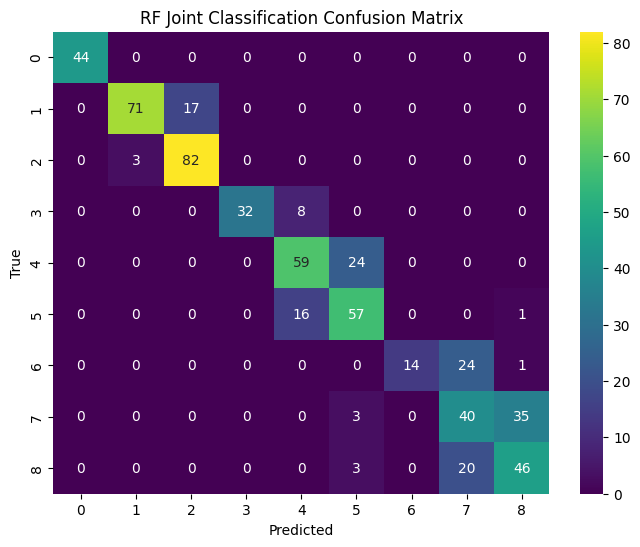

In [13]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("RF Joint Classification Confusion Matrix")

plt.show()

In [14]:
X_train_img, X_test_img, y_train_joint, y_test_joint = train_test_split(
    X, joint_labels, test_size=0.2, random_state=42
)

print(X_train_img.shape, X_test_img.shape)
print(y_train_joint.shape, y_test_joint.shape)

(2400, 128, 128) (600, 128, 128)
(2400,) (600,)


In [15]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [16]:
X_train_tensor = torch.tensor(X_train_img[:, None, :, :], dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_img[:, None, :, :], dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_joint, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_joint, dtype=torch.long)

train_ds = TensorDataset(X_train_tensor, y_train_tensor)
test_ds = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

In [17]:
class DiffractionCNNJoint(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, 9)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [18]:
model = DiffractionCNNJoint().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [21]:
n_epochs = 12
train_losses = []

for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1}/{n_epochs} - Train Loss: {epoch_loss:.6f}")

Epoch 1/12 - Train Loss: 0.159283
Epoch 2/12 - Train Loss: 0.137696
Epoch 3/12 - Train Loss: 0.165878
Epoch 4/12 - Train Loss: 0.136897
Epoch 5/12 - Train Loss: 0.146105
Epoch 6/12 - Train Loss: 0.100634
Epoch 7/12 - Train Loss: 0.115528
Epoch 8/12 - Train Loss: 0.134221
Epoch 9/12 - Train Loss: 0.106818
Epoch 10/12 - Train Loss: 0.077051
Epoch 11/12 - Train Loss: 0.126788
Epoch 12/12 - Train Loss: 0.095492


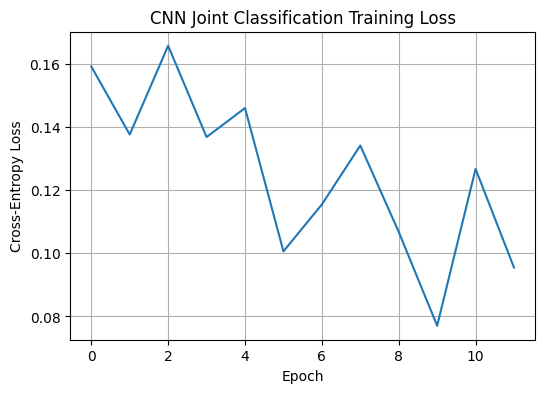

In [22]:
plt.figure(figsize=(6,4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("CNN Joint Classification Training Loss")
plt.grid(True)
plt.show()

In [23]:
model.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        all_preds.append(preds)
        all_true.append(yb.numpy())

y_pred_cnn = np.concatenate(all_preds)
y_true_cnn = np.concatenate(all_true)

In [24]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_true_cnn, y_pred_cnn))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        44
           1       0.95      0.84      0.89        88
           2       0.84      0.95      0.90        85
           3       1.00      0.97      0.99        40
           4       0.91      0.81      0.85        83
           5       0.81      0.86      0.84        74
           6       0.90      0.95      0.93        39
           7       0.82      0.82      0.82        78
           8       0.86      0.88      0.87        69

    accuracy                           0.89       600
   macro avg       0.90      0.90      0.90       600
weighted avg       0.89      0.89      0.88       600



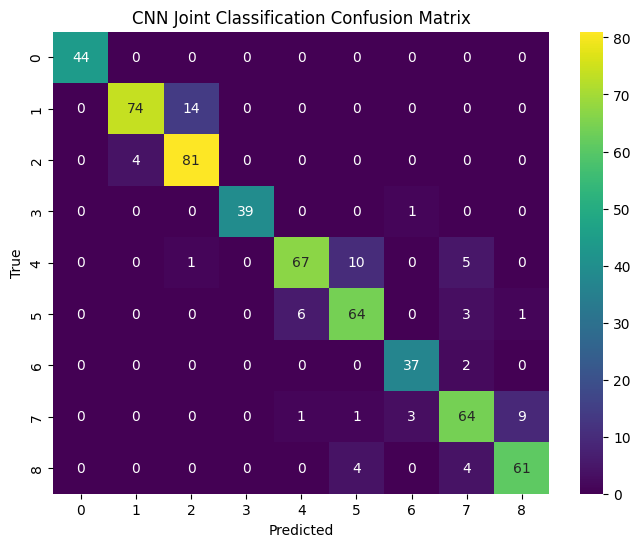

In [25]:
import seaborn as sns

cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)

plt.figure(figsize=(8,6))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='viridis')

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("CNN Joint Classification Confusion Matrix")

plt.show()

In [26]:
sigma_true = y_true_cnn // 3
sigma_pred = y_pred_cnn // 3

from sklearn.metrics import accuracy_score
print("Sigma classification accuracy:", accuracy_score(sigma_true, sigma_pred))

Sigma classification accuracy: 0.9716666666666667
